### Libraries are defined here

In [1]:
from sklearn.ensemble import RandomForestRegressor
import numpy as np

from sklearn import preprocessing
import pandas as pd
import matplotlib
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, RandomizedSearchCV

In [2]:
car_sales_Data = pd.read_csv("data/car-sales-extended.csv")

In [3]:
car_sales_Data


,Make,Colour,Odometer (KM),Doors,Price
0,Honda,White,35431,4,15323
1,BMW,Blue,192714,5,19943
2,Honda,White,84714,4,28343
3,Toyota,White,154365,4,13434
4,Nissan,Blue,181577,3,14043
...,...,...,...,...,...
995,Toyota,Black,35820,4,32042
996,Nissan,White,155144,3,5716
997,Nissan,Blue,66604,4,31570
998,Honda,White,215883,4,4001


### Data Preprocessing

In [4]:
column_categories = ["Make","Colour","Doors"]
processed = ColumnTransformer(transformers=[("one_hot",OneHotEncoder(),column_categories)],remainder="passthrough")

In [5]:
processed_data = processed.fit_transform(car_sales_Data)

In [6]:
redefined_data_set = pd.DataFrame(processed_data,columns=processed.get_feature_names_out())

In [7]:
redefined_data_set

,one_hot__Make_BMW,one_hot__Make_Honda,one_hot__Make_Nissan,one_hot__Make_Toyota,one_hot__Colour_Black,one_hot__Colour_Blue,one_hot__Colour_Green,one_hot__Colour_Red,one_hot__Colour_White,one_hot__Doors_3,one_hot__Doors_4,one_hot__Doors_5,remainder__Odometer (KM),remainder__Price
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,35431.0,15323.0
1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,192714.0,19943.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,84714.0,28343.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,154365.0,13434.0
4,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,181577.0,14043.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,35820.0,32042.0
996,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,155144.0,5716.0
997,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,66604.0,31570.0
998,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,215883.0,4001.0



### Data Splitting into test and train segment

In [8]:
X = redefined_data_set.drop("remainder__Price",axis=1)

In [9]:
X.head()

,one_hot__Make_BMW,one_hot__Make_Honda,one_hot__Make_Nissan,one_hot__Make_Toyota,one_hot__Colour_Black,one_hot__Colour_Blue,one_hot__Colour_Green,one_hot__Colour_Red,one_hot__Colour_White,one_hot__Doors_3,one_hot__Doors_4,one_hot__Doors_5,remainder__Odometer (KM)
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,35431.0
1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,192714.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,84714.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,154365.0
4,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,181577.0


In [10]:
y = redefined_data_set["remainder__Price"]

In [11]:
y.head()

0    15323.0
1    19943.0
2    28343.0
3    13434.0
4    14043.0
Name: remainder__Price, dtype: float64

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [13]:
y_train

29     13586.0
535    35683.0
695    16285.0
557    22825.0
836    20938.0
        ...   
106    13283.0
270     9379.0
860     5922.0
435     8753.0
102     7404.0
Name: remainder__Price, Length: 800, dtype: float64

In [14]:
clf = RandomForestRegressor(n_estimators=100)

In [15]:
clf

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [16]:
model=clf.fit(X_train,y_train)

In [17]:
model.score(X_test,y_test)

0.3087072006966378

In [18]:
rf_grid = {
    "n_estimators": [100, 200, 500],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 4, 6],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", 1.0]
}

rs_model = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=rf_grid,
    n_iter=20,
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)
rs_model.fit(X_train,y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,estimator,RandomForestR...ndom_state=42)
,param_distributions,"{'max_depth': [None, 5, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 4, ...], ...}"
,n_iter,20
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [19]:
rs_model.best_params_

{'n_estimators': 500,
 'min_samples_split': 6,
 'min_samples_leaf': 1,
 'max_features': 'log2',
 'max_depth': 5}

In [20]:
rs_model.score(X_test,y_test)

0.4148106532480552

In [21]:
car_sales_missing = pd.read_csv("data/car-sales-realistic.csv")

In [22]:
len(car_sales_missing)

10010

In [23]:
car_sales_missing.isna().sum()

Make        119
Colour      162
Odometer    210
Doors        96
Price       195
dtype: int64

### Option1: Fill the missing values using pandas

In [24]:
# Fill the "Make" Column
car_sales_missing["Make"].fillna("missing",inplace=True)

# Fill the "Colour" Column
car_sales_missing["Colour"].fillna("missing",inplace=True)

#Fill the Odometer Column

car_sales_missing["Odometer"].replace("missing",car_sales_missing.loc[car_sales_missing["Odometer"] != "missing", "Odometer"].astype(float).mean())
# Convert to float
car_sales_missing["Odometer"] = car_sales_missing["Odometer"].astype(float)
# Fill the Doors Column

car_sales_missing["Doors"].replace("missing",4)






0        4.0
1        4.0
2        3.0
3        5.0
4        4.0
        ... 
10005    4.0
10006    4.0
10007    4.0
10008    3.0
10009    4.0
Name: Doors, Length: 10010, dtype: float64

In [25]:
car_sales_missing.isin(["missing"]).sum()

Make        119
Colour      162
Odometer      0
Doors         0
Price         0
dtype: int64

In [26]:
car_sales_missing.isna().sum()

Make          0
Colour        0
Odometer    210
Doors        96
Price       195
dtype: int64

In [27]:
car_sales_missing.dropna(inplace=True)


In [28]:
len(car_sales_missing)

9522

In [29]:
X = car_sales_missing.drop("Price",axis=1)
y = car_sales_missing["Price"]

In [30]:
categorical_features = ["Make","Colour"]
one_hot = OneHotEncoder()

transformer = ColumnTransformer(transformers=[("one_hot",one_hot,categorical_features)],remainder="passthrough")

transformed_X = transformer.fit_transform(car_sales_missing)
transformed_X


array([[0.0, 0.0, 0.0, ..., 150043.0, 4.0, '$4,000'],
       [0.0, 1.0, 0.0, ..., 87899.0, 4.0, '$5,000'],
       [1.0, 0.0, 0.0, ..., 11179.0, 5.0, '$22,000'],
       ...,
       [0.0, 0.0, 0.0, ..., 144219.0, 4.0, '$10,800'],
       [0.0, 0.0, 0.0, ..., 147534.0, 4.0, '$9,300'],
       [0.0, 0.0, 0.0, ..., 169623.0, 3.0, '$7,100']],
      shape=(9522, 16), dtype=object)

In [31]:
car_sales_dataframe = pd.DataFrame(transformed_X, columns=transformer.get_feature_names_out())
car_sales_dataframe
car_sales_dataframe["remainder__Price"] = (
    car_sales_dataframe["remainder__Price"]
    .replace('[\\$,]', '', regex=True)
    .astype(float)
)
car_sales_dataframe.columns.to_list()




['one_hot__Make_BMW',
 'one_hot__Make_Honda',
 'one_hot__Make_Nissan',
 'one_hot__Make_Toyota',
 'one_hot__Make_missing',
 'one_hot__Colour_Black',
 'one_hot__Colour_Blue',
 'one_hot__Colour_Green',
 'one_hot__Colour_Grey',
 'one_hot__Colour_Red',
 'one_hot__Colour_Silver',
 'one_hot__Colour_White',
 'one_hot__Colour_missing',
 'remainder__Odometer',
 'remainder__Doors',
 'remainder__Price']

In [32]:
numeric_features = ["remainder__Odometer","remainder__Doors"]

transfer_clmn = ColumnTransformer(transformers=[("num",preprocessing.StandardScaler(),numeric_features)],remainder="passthrough")
transfered_fit = transfer_clmn.fit_transform(car_sales_dataframe)

transfered_fit

array([[1.040152567850928, -0.2761874689595444, 0.0, ..., 1.0, 0.0,
        4000.0],
       [-0.16846979314628013, -0.2761874689595444, 0.0, ..., 0.0, 0.0,
        5000.0],
       [-1.6605769561178592, 1.4852707222211574, 1.0, ..., 0.0, 0.0,
        22000.0],
       ...,
       [0.9268831189830125, -0.2761874689595444, 0.0, ..., 0.0, 0.0,
        10800.0],
       [0.991355684744884, -0.2761874689595444, 0.0, ..., 0.0, 0.0,
        9300.0],
       [1.4209588537083773, -2.0376456601402464, 0.0, ..., 1.0, 0.0,
        7100.0]], shape=(9522, 16), dtype=object)

In [33]:
transfered_df = pd.DataFrame(transfered_fit,columns=transfer_clmn.get_feature_names_out())
transfered_df

,num__remainder__Odometer,num__remainder__Doors,remainder__one_hot__Make_BMW,remainder__one_hot__Make_Honda,remainder__one_hot__Make_Nissan,remainder__one_hot__Make_Toyota,remainder__one_hot__Make_missing,remainder__one_hot__Colour_Black,remainder__one_hot__Colour_Blue,remainder__one_hot__Colour_Green,remainder__one_hot__Colour_Grey,remainder__one_hot__Colour_Red,remainder__one_hot__Colour_Silver,remainder__one_hot__Colour_White,remainder__one_hot__Colour_missing,remainder__remainder__Price
0,1.040153,-0.276187,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,4000.0
1,-0.16847,-0.276187,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,5000.0
2,-1.660577,1.485271,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,22000.0
3,2.266434,-0.276187,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3500.0
4,-1.263414,-0.276187,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,9700.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9517,1.812501,1.485271,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,4300.0
9518,1.274821,-0.276187,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,5500.0
9519,0.926883,-0.276187,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,10800.0
9520,0.991356,-0.276187,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9300.0


In [34]:
X = transfered_df.drop("remainder__remainder__Price",axis=1)
y = transfered_df["remainder__remainder__Price"]
y
X.head()

,num__remainder__Odometer,num__remainder__Doors,remainder__one_hot__Make_BMW,remainder__one_hot__Make_Honda,remainder__one_hot__Make_Nissan,remainder__one_hot__Make_Toyota,remainder__one_hot__Make_missing,remainder__one_hot__Colour_Black,remainder__one_hot__Colour_Blue,remainder__one_hot__Colour_Green,remainder__one_hot__Colour_Grey,remainder__one_hot__Colour_Red,remainder__one_hot__Colour_Silver,remainder__one_hot__Colour_White,remainder__one_hot__Colour_missing
0,1.040153,-0.276187,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,-0.16847,-0.276187,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,-1.660577,1.485271,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2.266434,-0.276187,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,-1.263414,-0.276187,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [35]:
X_train, X_test, y_train, y_test = train_test_split(X,y,random_state=42,test_size=0.2)

In [36]:
X_train

,num__remainder__Odometer,num__remainder__Doors,remainder__one_hot__Make_BMW,remainder__one_hot__Make_Honda,remainder__one_hot__Make_Nissan,remainder__one_hot__Make_Toyota,remainder__one_hot__Make_missing,remainder__one_hot__Colour_Black,remainder__one_hot__Colour_Blue,remainder__one_hot__Colour_Green,remainder__one_hot__Colour_Grey,remainder__one_hot__Colour_Red,remainder__one_hot__Colour_Silver,remainder__one_hot__Colour_White,remainder__one_hot__Colour_missing
2955,2.050865,-0.276187,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5246,0.649836,-0.276187,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
6196,-0.861973,-0.276187,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
6432,-1.288386,1.485271,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
9213,0.949619,-0.276187,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5734,-0.625885,1.485271,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5191,-0.882958,-0.276187,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
5390,-0.276002,1.485271,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
860,-1.231402,-0.276187,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [37]:
clf = RandomForestRegressor(n_estimators=100)

In [38]:
model = clf.fit(X_train,y_train)

In [39]:
model.score(X_test,y_test)*100

67.24461848781887

In [40]:
reg_grid = {
    "n_estimators":[100,200,500],
    "max_depth":[None,5,10,20],
    "min_samples_split":[2,4,6],
    "min_samples_leaf":[1,2,4],
    "max_features":["sqrt","log2",1.0]
}

reg_model = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=reg_grid,
    n_iter = 20,
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

reg_model

,estimator,RandomForestR...ndom_state=42)
,param_distributions,"{'max_depth': [None, 5, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 4, ...], ...}"
,n_iter,20
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [41]:
reg_model.fit(X_train,y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,estimator,RandomForestR...ndom_state=42)
,param_distributions,"{'max_depth': [None, 5, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 4, ...], ...}"
,n_iter,20
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [42]:
reg_model.score(X_test,y_test)

0.723206370912791

In [43]:
X_test.head()

,num__remainder__Odometer,num__remainder__Doors,remainder__one_hot__Make_BMW,remainder__one_hot__Make_Honda,remainder__one_hot__Make_Nissan,remainder__one_hot__Make_Toyota,remainder__one_hot__Make_missing,remainder__one_hot__Colour_Black,remainder__one_hot__Colour_Blue,remainder__one_hot__Colour_Green,remainder__one_hot__Colour_Grey,remainder__one_hot__Colour_Red,remainder__one_hot__Colour_Silver,remainder__one_hot__Colour_White,remainder__one_hot__Colour_missing
7088,1.063277,1.485271,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2036,0.617084,-0.276187,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
457,-1.266837,-0.276187,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
9156,-0.259859,-0.276187,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
321,-0.075719,-0.276187,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [44]:
predictions = reg_model.predict(X_test)
predictions

array([ 8064.48181155,  9937.1406507 , 13290.64441386, ...,
        9414.57657026,  6821.6165969 ,  5269.30499482], shape=(1905,))

In [45]:
comparison = pd.DataFrame({
    "Actual":y_test,
    "Predicted":predictions
})
comparison.to_csv("data/comparison.csv")

In [46]:
reg_model.best_estimator_.feature_importances_

array([0.23802442, 0.02139102, 0.50656915, 0.03665114, 0.07555732,
       0.03942093, 0.00324026, 0.00203194, 0.00121486, 0.00198504,
       0.05707835, 0.00773921, 0.00705864, 0.00141253, 0.00062521])

In [47]:
%matplotlib inline 
matplotlib.style.use('ggplot')

In [48]:
np.random.seed(1)
plot_dataFrame = pd.read_csv("data/comparison.csv")
plot_dataFrame.head()

,Unnamed: 0,Actual,Predicted
0,7088,12600.0,8064.481812
1,2036,2500.0,9937.140651
2,457,16100.0,13290.644414
3,9156,6600.0,9938.008818
4,321,9200.0,9573.702932


In [49]:
plot_data = pd.DataFrame({
    'x1':plot_dataFrame["Actual"],
    'x2':plot_dataFrame["Predicted"]
    
})
plot_data

,x1,x2
0,12600.0,8064.481812
1,2500.0,9937.140651
2,16100.0,13290.644414
3,6600.0,9938.008818
4,9200.0,9573.702932
...,...,...
1900,9100.0,10994.937882
1901,9900.0,5946.610372
1902,10000.0,9414.576570
1903,10100.0,6821.616597


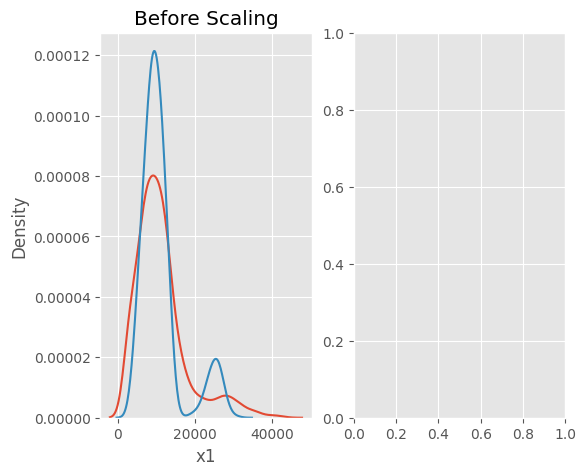

In [50]:
fig, (ax1, ax2) = plt.subplots(ncols=2,figsize=(6,5))
ax1.set_title("Before Scaling")
sns.kdeplot(plot_data['x1'],ax=ax1)
sns.kdeplot(plot_data['x2'],ax=ax1)
scaler = preprocessing.StandardScaler()




In [51]:
## After scaling
car_sales_missing = pd.read_csv("data/car-sales-realistic.csv")
car_sales_missing




,Make,Colour,Odometer,Doors,Price
0,Toyota,White,150043.0,4.0,"$4,000"
1,Honda,Red,87899.0,4.0,"$5,000"
2,Toyota,Blue,NaN,3.0,"$7,000"
3,BMW,Black,11179.0,5.0,"$22,000"
4,Nissan,White,213095.0,4.0,"$3,500"
...,...,...,...,...,...
10005,Toyota,Red,162109.0,4.0,"$5,500"
10006,Toyota,Red,144219.0,4.0,"$10,800"
10007,Toyota,Black,147534.0,4.0,"$9,300"
10008,Toyota,White,169623.0,3.0,"$7,100"


In [52]:
car_sales_missing.isna().sum()

Make        119
Colour      162
Odometer    210
Doors        96
Price       195
dtype: int64

In [53]:
car_sales_missing.dropna(subset=["Price"],inplace=True)
car_sales_missing.isna().sum()

Make        117
Colour      160
Odometer    203
Doors        91
Price         0
dtype: int64

In [54]:
car_sales_missing.head()

,Make,Colour,Odometer,Doors,Price
0,Toyota,White,150043.0,4.0,"$4,000"
1,Honda,Red,87899.0,4.0,"$5,000"
2,Toyota,Blue,NaN,3.0,"$7,000"
3,BMW,Black,11179.0,5.0,"$22,000"
4,Nissan,White,213095.0,4.0,"$3,500"


In [55]:
car_sales_missing["Pricing"] = (car_sales_missing["Price"].replace('[\\$,]','',regex=True).astype(float))

In [56]:
car_sales_missing["Pricing"]

0         4000.0
1         5000.0
2         7000.0
3        22000.0
4         3500.0
          ...   
10005     5500.0
10006    10800.0
10007     9300.0
10008     7100.0
10009     2500.0
Name: Pricing, Length: 9815, dtype: float64

In [57]:
X = car_sales_missing.drop("Pricing",axis=1)
y = car_sales_missing["Pricing"]
y

0         4000.0
1         5000.0
2         7000.0
3        22000.0
4         3500.0
          ...   
10005     5500.0
10006    10800.0
10007     9300.0
10008     7100.0
10009     2500.0
Name: Pricing, Length: 9815, dtype: float64

In [58]:
## Filling missing values with Scikit-learn
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

## Fill categorical values with missing and numerical value with mean

cat_imputer = SimpleImputer(strategy="constant",fill_value="missing")
door_imputer = SimpleImputer(strategy="constant", fill_value=4)
num_imputer = SimpleImputer(strategy="mean")

cat_features = ["Make","Colour"]
door_features = ["Doors"]
num_features = ["Odometer"]

# Create an imputer (something that fills missing data)

imputer = ColumnTransformer([("cat_imputer",cat_imputer,cat_features),
                            ("door_imputer",door_imputer,door_features),
                            ("num_imputer",num_imputer,num_features)])

# Transform the data

filled_X = imputer.fit_transform(X)
filled_X

array([['Toyota', 'White', 4.0, 150043.0],
       ['Honda', 'Red', 4.0, 87899.0],
       ['Toyota', 'Blue', 3.0, 96611.96525176862],
       ...,
       ['Toyota', 'Black', 4.0, 147534.0],
       ['Toyota', 'White', 3.0, 169623.0],
       ['Nissan', 'Silver', 4.0, 96611.96525176862]],
      shape=(9815, 4), dtype=object)

In [59]:
car_sales_filled = pd.DataFrame(filled_X,columns=["Make","Colour","Doors","Odometer"])
car_sales_filled.head()

,Make,Colour,Doors,Odometer
0,Toyota,White,4.0,150043.0
1,Honda,Red,4.0,87899.0
2,Toyota,Blue,3.0,96611.965252
3,BMW,Black,5.0,11179.0
4,Nissan,White,4.0,213095.0


In [60]:
car_sales_filled.isna().sum()

Make        0
Colour      0
Doors       0
Odometer    0
dtype: int64

In [61]:
car_sales_filled

,Make,Colour,Doors,Odometer
0,Toyota,White,4.0,150043.0
1,Honda,Red,4.0,87899.0
2,Toyota,Blue,3.0,96611.965252
3,BMW,Black,5.0,11179.0
4,Nissan,White,4.0,213095.0
...,...,...,...,...
9810,Toyota,Red,4.0,162109.0
9811,Toyota,Red,4.0,144219.0
9812,Toyota,Black,4.0,147534.0
9813,Toyota,White,3.0,169623.0


In [62]:
categorical_features = ["Make","Colour"]

one_hot = OneHotEncoder()
transformer = ColumnTransformer([("one_hot",OneHotEncoder(),categorical_features)],remainder="passthrough")
transformed_X = transformer.fit_transform(car_sales_filled)

transformed_X

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 39260 stored elements and shape (9815, 15)>

In [63]:
## Let's fit a model

np.random.seed(42)
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(transformed_X,y,test_size=0.2)

model = RandomForestRegressor()
model.fit(X_train,y_train)
model.score(X_test,y_test)

0.6565952187623434

In [64]:
reg_grid = {
    "n_estimators":[100,200,500],
    "max_depth":[None,5,10,20],
    "min_samples_split":[2,4,6],
    "min_samples_leaf":[1,2,4],
    "max_features":["sqrt","log2",1.0]
}

reg_model = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=reg_grid,
    n_iter = 20,
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

reg_model.fit(X_train,y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV] END max_depth=5, max_features=log2, min_samples_leaf=4, min_samples_split=6, n_estimators=100; total time=   0.1s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=2, min_samples_split=2, n_estimators=100; total time=   0.0s
[CV] END max_depth=5, max_features=log2, min_samples_leaf=4, min_samples_split=2, n_estimators=100; total time=   0.0s
[CV] END max_depth=10, max_features=log2, min_samples_leaf=1, min_samples_split=6, n_estimators=200; total time=   0.1s
[CV] END max_depth=5, max_features=1.0, min_samples_leaf=2, min_samples_split=2, n_estimators=100; total time=   0.1s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=2, min_samples_split=6, n_estimators=500; total time=   0.3s
[CV] END max_depth=10, max_features=1.0, min_samples_leaf=2, min_samples_split=2, n_estimators=200; total time=   0.2s
[CV] END max_depth=5, max_features=log2, min_samples_leaf=1, min_samples_split=6, n_estimators=500; t

,estimator,RandomForestR...ndom_state=42)
,param_distributions,"{'max_depth': [None, 5, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 4, ...], ...}"
,n_iter,20
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [65]:
reg_model.score(X_test,y_test)

0.7103268317768382

[CV] END max_depth=5, max_features=log2, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.0s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=4, min_samples_split=2, n_estimators=100; total time=   0.0s
[CV] END max_depth=10, max_features=1.0, min_samples_leaf=1, min_samples_split=4, n_estimators=100; total time=   0.1s
[CV] END max_depth=20, max_features=sqrt, min_samples_leaf=4, min_samples_split=4, n_estimators=500; total time=   0.2s
[CV] END max_depth=10, max_features=1.0, min_samples_leaf=2, min_samples_split=2, n_estimators=200; total time=   0.2s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=4, min_samples_split=6, n_estimators=100; total time=   0.0s
[CV] END max_depth=20, max_features=log2, min_samples_leaf=4, min_samples_split=6, n_estimators=500; total time=   0.2s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=4, min_samples_split=6, n_estimators=200; total time=   0.1s
[CV] END max_depth=None, max_features=sqr